# Pregunta 1

# Caso axial

T_amb estimada = 14.11 °C
Masa de escoria = 67.79 kg
Área ducto = 0.002027 m2
Inicio descarga detectado en t = 1.5528 h
T_out al inicio descarga = 134.46 °C
t_cut desde inicio de descarga = 534.14 s

resultados A1 
Energía útil recuperada hasta T_out = 100°C: 0.4902 kWh
Capacidad térmica teórica máxima del lecho: 2.8147 kWh
Factor de utilización U: 0.17417
Factor de utilización U: 17.417 %

 datos experimentales de descarga útil
Tiempo útil experimental = 0.1484 h
Potencia final experimental = 2.7169 kW
Energía útil experimental = 0.4902 kWh
Masa experimental = 67.79 kg

 escalamiento por curva de potencia 
Factor de duración = 26.96
Factor de potencia = 36.81
Masa requerida por potencia final = 67266.04 kg
Masa requerida por potencia final = 67.27 toneladas

 escalamiento por energía total
Energía requerida = 400.00 kWh
Masa requerida por energía = 55309.91 kg
Masa requerida por energía = 55.31 toneladas

 resultado final
Masa requerida final = 67266.04 kg
Masa requerida final = 67.27

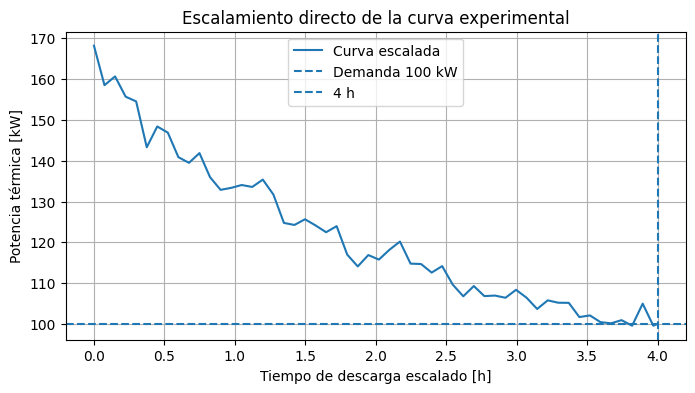

In [29]:
import pandas as pd
import numpy as np

path = "Ensayo T-150°C 1.30 2023-08-16.xlsx"

df = pd.read_excel(path, header=8)
df.columns = df.columns.str.strip()

df = df.dropna(how="all")
df = df[df["Scan Number"].notna()].copy()

time_col = "Scan Sweep Time (Sec)"
Tout_col = "101 (°C)- T1"
Vair_col = "111 (Vdc)- V_aire"

df["t_s"] = (df[time_col] - df[time_col].iloc[0]).dt.total_seconds()
df["t_h"] = df["t_s"] / 3600

rho_slag = 3700
cp_slag = 1100
epsilon = 0.46
T_charge = 150

D_bed = 0.280
H_bed = 0.551

V_bed = np.pi * D_bed**2 / 4 * H_bed
m_slag = (1 - epsilon) * rho_slag * V_bed

D_duct = 2 * 0.0254
A_duct = np.pi * D_duct**2 / 4

temp_cols = [col for col in df.columns if "(°C)" in col]
T_amb = df.loc[df["t_h"] < 0.05, temp_cols].mean().mean()

print(f"T_amb estimada = {T_amb:.2f} °C")
print(f"Masa de escoria = {m_slag:.2f} kg")
print(f"Área ducto = {A_duct:.6f} m2")

df["dTout_dt"] = df[Tout_col].diff() / df["t_s"].diff()

t_charge_h = 1.5

candidatos_descarga = df[
    (df["t_h"] > t_charge_h - 0.05) &
    (df["dTout_dt"] < -0.05)
]

idx_start_discharge = candidatos_descarga.index[0]

t_start_discharge_s = df.loc[idx_start_discharge, "t_s"]
t_start_discharge_h = df.loc[idx_start_discharge, "t_h"]

print(f"Inicio descarga detectado en t = {t_start_discharge_h:.4f} h")
print(f"T_out al inicio descarga = {df.loc[idx_start_discharge, Tout_col]:.2f} °C")

T_cut = 100

df_dis = df.loc[idx_start_discharge:].copy()

idx_cross = df_dis[df_dis[Tout_col] < T_cut].index[0]
idx_prev = idx_cross - 1

t0 = df.loc[idx_prev, "t_s"]
t1 = df.loc[idx_cross, "t_s"]

T0 = df.loc[idx_prev, Tout_col]
T1 = df.loc[idx_cross, Tout_col]

frac = (T_cut - T0) / (T1 - T0)

t_cut_s_abs = t0 + frac * (t1 - t0)
t_cut_s = t_cut_s_abs - t_start_discharge_s

print(f"t_cut desde inicio de descarga = {t_cut_s:.2f} s")

P_atm = 101325
R_air = 287.05

def rho_air_ideal(T_C, P=P_atm):
    T_K = T_C + 273.15
    return P / (R_air * T_K)

def cp_air_approx(T_C):
    return 1007.0

data = df.loc[idx_start_discharge:idx_prev].copy()

row_prev = df.loc[idx_prev].copy()
row_cross = df.loc[idx_cross].copy()

row_cut = row_prev + frac * (row_cross - row_prev)
row_cut["t_s"] = t_cut_s_abs
row_cut["t_h"] = t_cut_s_abs / 3600
row_cut[Tout_col] = T_cut

data = pd.concat([data, pd.DataFrame([row_cut])], ignore_index=True)

data["t_dis_s"] = data["t_s"] - t_start_discharge_s

data["u_air"] = 25 * data[Vair_col]

rho_air = rho_air_ideal(T_amb)

data["m_dot"] = rho_air * A_duct * data["u_air"]

data["cp_air"] = data[Tout_col].apply(cp_air_approx)

data["Qdot_rec_W"] = (
    data["m_dot"] *
    data["cp_air"] *
    (data[Tout_col] - T_amb)
)

data["Qdot_rec_kW"] = data["Qdot_rec_W"] / 1000

Q_rec_J = np.trapezoid(data["Qdot_rec_W"], data["t_dis_s"])
Q_rec_kWh = Q_rec_J / 3.6e6

Q_max_J = m_slag * cp_slag * (T_charge - T_amb)
Q_max_kWh = Q_max_J / 3.6e6

U = Q_rec_J / Q_max_J

print("\nresultados A1 ")
print(f"Energía útil recuperada hasta T_out = 100°C: {Q_rec_kWh:.4f} kWh")
print(f"Capacidad térmica teórica máxima del lecho: {Q_max_kWh:.4f} kWh")
print(f"Factor de utilización U: {U:.5f}")
print(f"Factor de utilización U: {U*100:.3f} %")

P_req_kW = 100
t_req_h = 4
E_req_kWh = P_req_kW * t_req_h

cp_slag_kWh = 1.1 / 3600

t_util_exp_s = data["t_dis_s"].iloc[-1]
t_util_exp_h = t_util_exp_s / 3600

P_final_exp_kW = data["Qdot_rec_kW"].iloc[-1]

Q_util_exp_kWh = np.trapezoid(data["Qdot_rec_kW"], data["t_dis_s"]) / 3600

print("\n datos experimentales de descarga útil")
print(f"Tiempo útil experimental = {t_util_exp_h:.4f} h")
print(f"Potencia final experimental = {P_final_exp_kW:.4f} kW")
print(f"Energía útil experimental = {Q_util_exp_kWh:.4f} kWh")
print(f"Masa experimental = {m_slag:.2f} kg")

factor_duracion = t_req_h / t_util_exp_h

factor_potencia = P_req_kW / P_final_exp_kW

m_P = m_slag * factor_duracion * factor_potencia

print("\n escalamiento por curva de potencia ")
print(f"Factor de duración = {factor_duracion:.2f}")
print(f"Factor de potencia = {factor_potencia:.2f}")
print(f"Masa requerida por potencia final = {m_P:.2f} kg")
print(f"Masa requerida por potencia final = {m_P/1000:.2f} toneladas")

m_E = E_req_kWh / (U * cp_slag_kWh * (T_charge - T_amb))

print("\n escalamiento por energía total")
print(f"Energía requerida = {E_req_kWh:.2f} kWh")
print(f"Masa requerida por energía = {m_E:.2f} kg")
print(f"Masa requerida por energía = {m_E/1000:.2f} toneladas")

m_req = max(m_P, m_E)

print("\n resultado final")
print(f"Masa requerida final = {m_req:.2f} kg")
print(f"Masa requerida final = {m_req/1000:.2f} toneladas")

if m_P > m_E:
    print("Controla la condición de potencia al final de las 4 h.")
else:
    print("Controla la condición de energía total.")

import matplotlib.pyplot as plt

data["t_dis_h"] = data["t_dis_s"] / 3600
data["t_ind_h"] = data["t_dis_h"] * factor_duracion
data["Qdot_ind_kW"] = data["Qdot_rec_kW"] * factor_potencia

plt.figure(figsize=(8, 4))
plt.plot(data["t_ind_h"], data["Qdot_ind_kW"], label="Curva escalada")
plt.axhline(100, linestyle="--", label="Demanda 100 kW")
plt.axvline(4, linestyle="--", label="4 h")
plt.xlabel("Tiempo de descarga escalado [h]")
plt.ylabel("Potencia térmica [kW]")
plt.title("Escalamiento directo de la curva experimental")
plt.grid(True)
plt.legend()
plt.show()

['104 (°C)- T4', '105 (°C)- T5', '106 (°C)- T6', '107 (°C)- T7', '108 (°C)- T8', '109 (°C)- T9']
T_amb estimada = 19.79 °C
Masa de escoria = 14.86 kg
Área ducto = 0.002027 m2
Inicio descarga detectado en t = 4.3917 h
T_out al inicio descarga = 183.96 °C
t_cut desde inicio de descarga = 1215.69 s

resultados R4 
Energía útil recuperada hasta T_out = 100°C: 0.8355 kWh
Capacidad térmica teórica máxima del lecho: 1.2726 kWh
Factor de utilización U: 0.65654
Factor de utilización U: 65.654 %

 datos experimentales R4 
Tiempo útil experimental = 0.3377 h
Potencia final experimental = 1.7668 kW
Energía útil experimental = 0.8355 kWh
Masa experimental = 14.86 kg

 escalamiento por potencia final R4 
Factor de duración = 11.85
Factor de potencia = 56.60
Masa requerida por potencia final = 9965.09 kg
Masa requerida por potencia final = 9.97 toneladas

 escalamiento por energía total R4 
Energía requerida = 400.00 kWh
Masa requerida por energía = 7115.84 kg
Masa requerida por energía = 7.12 tonela

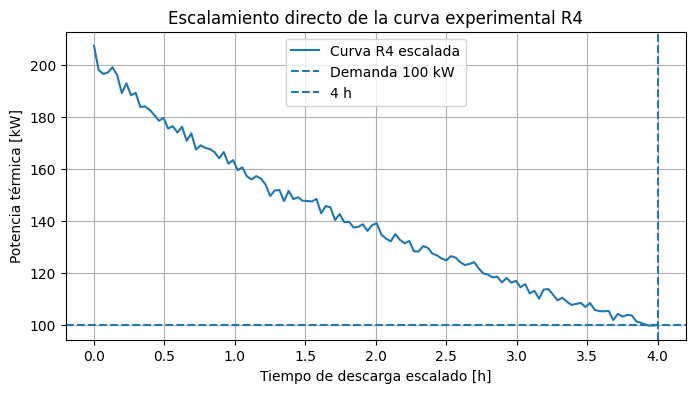

In [30]:
#caso radial

path = "Ensayo Prototipo T-300°C 3;00 2023-12-20-1.xlsx"

df = pd.read_excel(path, header=75)

df.columns = df.columns.astype(str).str.strip()

df = df.dropna(axis=1, how="all")
df = df.dropna(how="all")

df = df[df["Scan Number"].notna()].copy()

time_col = "Scan Sweep Time (Sec)"
T_inner_ids = ["T4", "T5", "T6", "T7", "T8", "T9"]

T_inner_cols = [
    col for col in df.columns
    if "(°C)" in col and any(f"- {tid}" in col or col.endswith(tid) for tid in T_inner_ids)
]

print(T_inner_cols)

df["T_out"] = df[T_inner_cols].mean(axis=1)

Tout_col = "T_out"
Vair_col = "111 (Vdc)- V_aire"

df["t_s"] = (df[time_col] - df[time_col].iloc[0]).dt.total_seconds()
df["t_h"] = df["t_s"] / 3600

rho_slag = 3700
cp_slag = 1100
epsilon = 0.63
T_charge = 300

D_outer = 0.240
D_inner = 0.060
H_bed = 0.256

V_bed = np.pi / 4 * (D_outer**2 - D_inner**2) * H_bed
m_slag = (1 - epsilon) * rho_slag * V_bed

D_duct = 2 * 0.0254
A_duct = np.pi * D_duct**2 / 4

temp_cols = [col for col in df.columns if "(°C)" in col]
T_amb = df.loc[df["t_h"] < 0.05, temp_cols].mean().mean()

print(f"T_amb estimada = {T_amb:.2f} °C")
print(f"Masa de escoria = {m_slag:.2f} kg")
print(f"Área ducto = {A_duct:.6f} m2")

df["dTout_dt"] = df[Tout_col].diff() / df["t_s"].diff()

t_charge_h = 3.0

candidatos_descarga = df[
    (df["t_h"] > t_charge_h - 0.05) &
    (df["dTout_dt"] < -0.05)
]

idx_start_discharge = candidatos_descarga.index[0]

t_start_discharge_s = df.loc[idx_start_discharge, "t_s"]
t_start_discharge_h = df.loc[idx_start_discharge, "t_h"]

print(f"Inicio descarga detectado en t = {t_start_discharge_h:.4f} h")
print(f"T_out al inicio descarga = {df.loc[idx_start_discharge, Tout_col]:.2f} °C")

T_cut = 100

df_dis = df.loc[idx_start_discharge:].copy()

idx_cross = df_dis[df_dis[Tout_col] < T_cut].index[0]
idx_prev = idx_cross - 1

t0 = df.loc[idx_prev, "t_s"]
t1 = df.loc[idx_cross, "t_s"]

T0 = df.loc[idx_prev, Tout_col]
T1 = df.loc[idx_cross, Tout_col]

frac = (T_cut - T0) / (T1 - T0)

t_cut_s_abs = t0 + frac * (t1 - t0)
t_cut_s = t_cut_s_abs - t_start_discharge_s

print(f"t_cut desde inicio de descarga = {t_cut_s:.2f} s")

P_atm = 101325
R_air = 287.05

def rho_air_ideal(T_C, P=P_atm):
    T_K = T_C + 273.15
    return P / (R_air * T_K)

def cp_air_approx(T_C):
    return 1007.0

data = df.loc[idx_start_discharge:idx_prev].copy()

row_prev = df.loc[idx_prev].copy()
row_cross = df.loc[idx_cross].copy()

row_cut = row_prev + frac * (row_cross - row_prev)
row_cut["t_s"] = t_cut_s_abs
row_cut["t_h"] = t_cut_s_abs / 3600
row_cut[Tout_col] = T_cut

data = pd.concat([data, pd.DataFrame([row_cut])], ignore_index=True)

data["t_dis_s"] = data["t_s"] - t_start_discharge_s

data["u_air"] = 25 * data[Vair_col]

rho_air = rho_air_ideal(T_amb)

data["m_dot"] = rho_air * A_duct * data["u_air"]

data["cp_air"] = data[Tout_col].apply(cp_air_approx)

data["Qdot_rec_W"] = (
    data["m_dot"] *
    data["cp_air"] *
    (data[Tout_col] - T_amb)
)

data["Qdot_rec_kW"] = data["Qdot_rec_W"] / 1000

Q_rec_J = np.trapezoid(data["Qdot_rec_W"], data["t_dis_s"])
Q_rec_kWh = Q_rec_J / 3.6e6

Q_max_J = m_slag * cp_slag * (T_charge - T_amb)
Q_max_kWh = Q_max_J / 3.6e6

U = Q_rec_J / Q_max_J

print("\nresultados R4 ")
print(f"Energía útil recuperada hasta T_out = 100°C: {Q_rec_kWh:.4f} kWh")
print(f"Capacidad térmica teórica máxima del lecho: {Q_max_kWh:.4f} kWh")
print(f"Factor de utilización U: {U:.5f}")
print(f"Factor de utilización U: {U*100:.3f} %")

P_req_kW = 100
t_req_h = 4
E_req_kWh = P_req_kW * t_req_h

cp_slag_kWh = 1.1 / 3600

t_util_exp_s = data["t_dis_s"].iloc[-1]
t_util_exp_h = t_util_exp_s / 3600

P_final_exp_kW = data["Qdot_rec_kW"].iloc[-1]

Q_util_exp_kWh = np.trapezoid(data["Qdot_rec_kW"], data["t_dis_s"]) / 3600

print("\n datos experimentales R4 ")
print(f"Tiempo útil experimental = {t_util_exp_h:.4f} h")
print(f"Potencia final experimental = {P_final_exp_kW:.4f} kW")
print(f"Energía útil experimental = {Q_util_exp_kWh:.4f} kWh")
print(f"Masa experimental = {m_slag:.2f} kg")

factor_duracion = t_req_h / t_util_exp_h
factor_potencia = P_req_kW / P_final_exp_kW

m_P = m_slag * factor_duracion * factor_potencia

print("\n escalamiento por potencia final R4 ")
print(f"Factor de duración = {factor_duracion:.2f}")
print(f"Factor de potencia = {factor_potencia:.2f}")
print(f"Masa requerida por potencia final = {m_P:.2f} kg")
print(f"Masa requerida por potencia final = {m_P/1000:.2f} toneladas")

m_E = E_req_kWh / (U * cp_slag_kWh * (T_charge - T_amb))

print("\n escalamiento por energía total R4 ")
print(f"Energía requerida = {E_req_kWh:.2f} kWh")
print(f"Masa requerida por energía = {m_E:.2f} kg")
print(f"Masa requerida por energía = {m_E/1000:.2f} toneladas")

m_req = max(m_P, m_E)

print("\n resultado final R4 ")
print(f"Masa requerida final = {m_req:.2f} kg")
print(f"Masa requerida final = {m_req/1000:.2f} toneladas")

if m_P > m_E:
    print("Controla la condición de potencia al final de las 4 h.")
else:
    print("Controla la condición de energía total.")

E_util_con_m_req = m_req * U * cp_slag_kWh * (T_charge - T_amb)

print("\n chequeo con masa final ")
print(f"Energía útil estimada con masa final = {E_util_con_m_req:.2f} kWh")
print(f"Energía demandada = {E_req_kWh:.2f} kWh")

import matplotlib.pyplot as plt

data["t_dis_h"] = data["t_dis_s"] / 3600
data["t_ind_h"] = data["t_dis_h"] * factor_duracion
data["Qdot_ind_kW"] = data["Qdot_rec_kW"] * factor_potencia

plt.figure(figsize=(8, 4))
plt.plot(data["t_ind_h"], data["Qdot_ind_kW"], label="Curva R4 escalada")
plt.axhline(100, linestyle="--", label="Demanda 100 kW")
plt.axvline(4, linestyle="--", label="4 h")
plt.xlabel("Tiempo de descarga escalado [h]")
plt.ylabel("Potencia térmica [kW]")
plt.title("Escalamiento directo de la curva experimental R4")
plt.grid(True)
plt.legend()
plt.show()